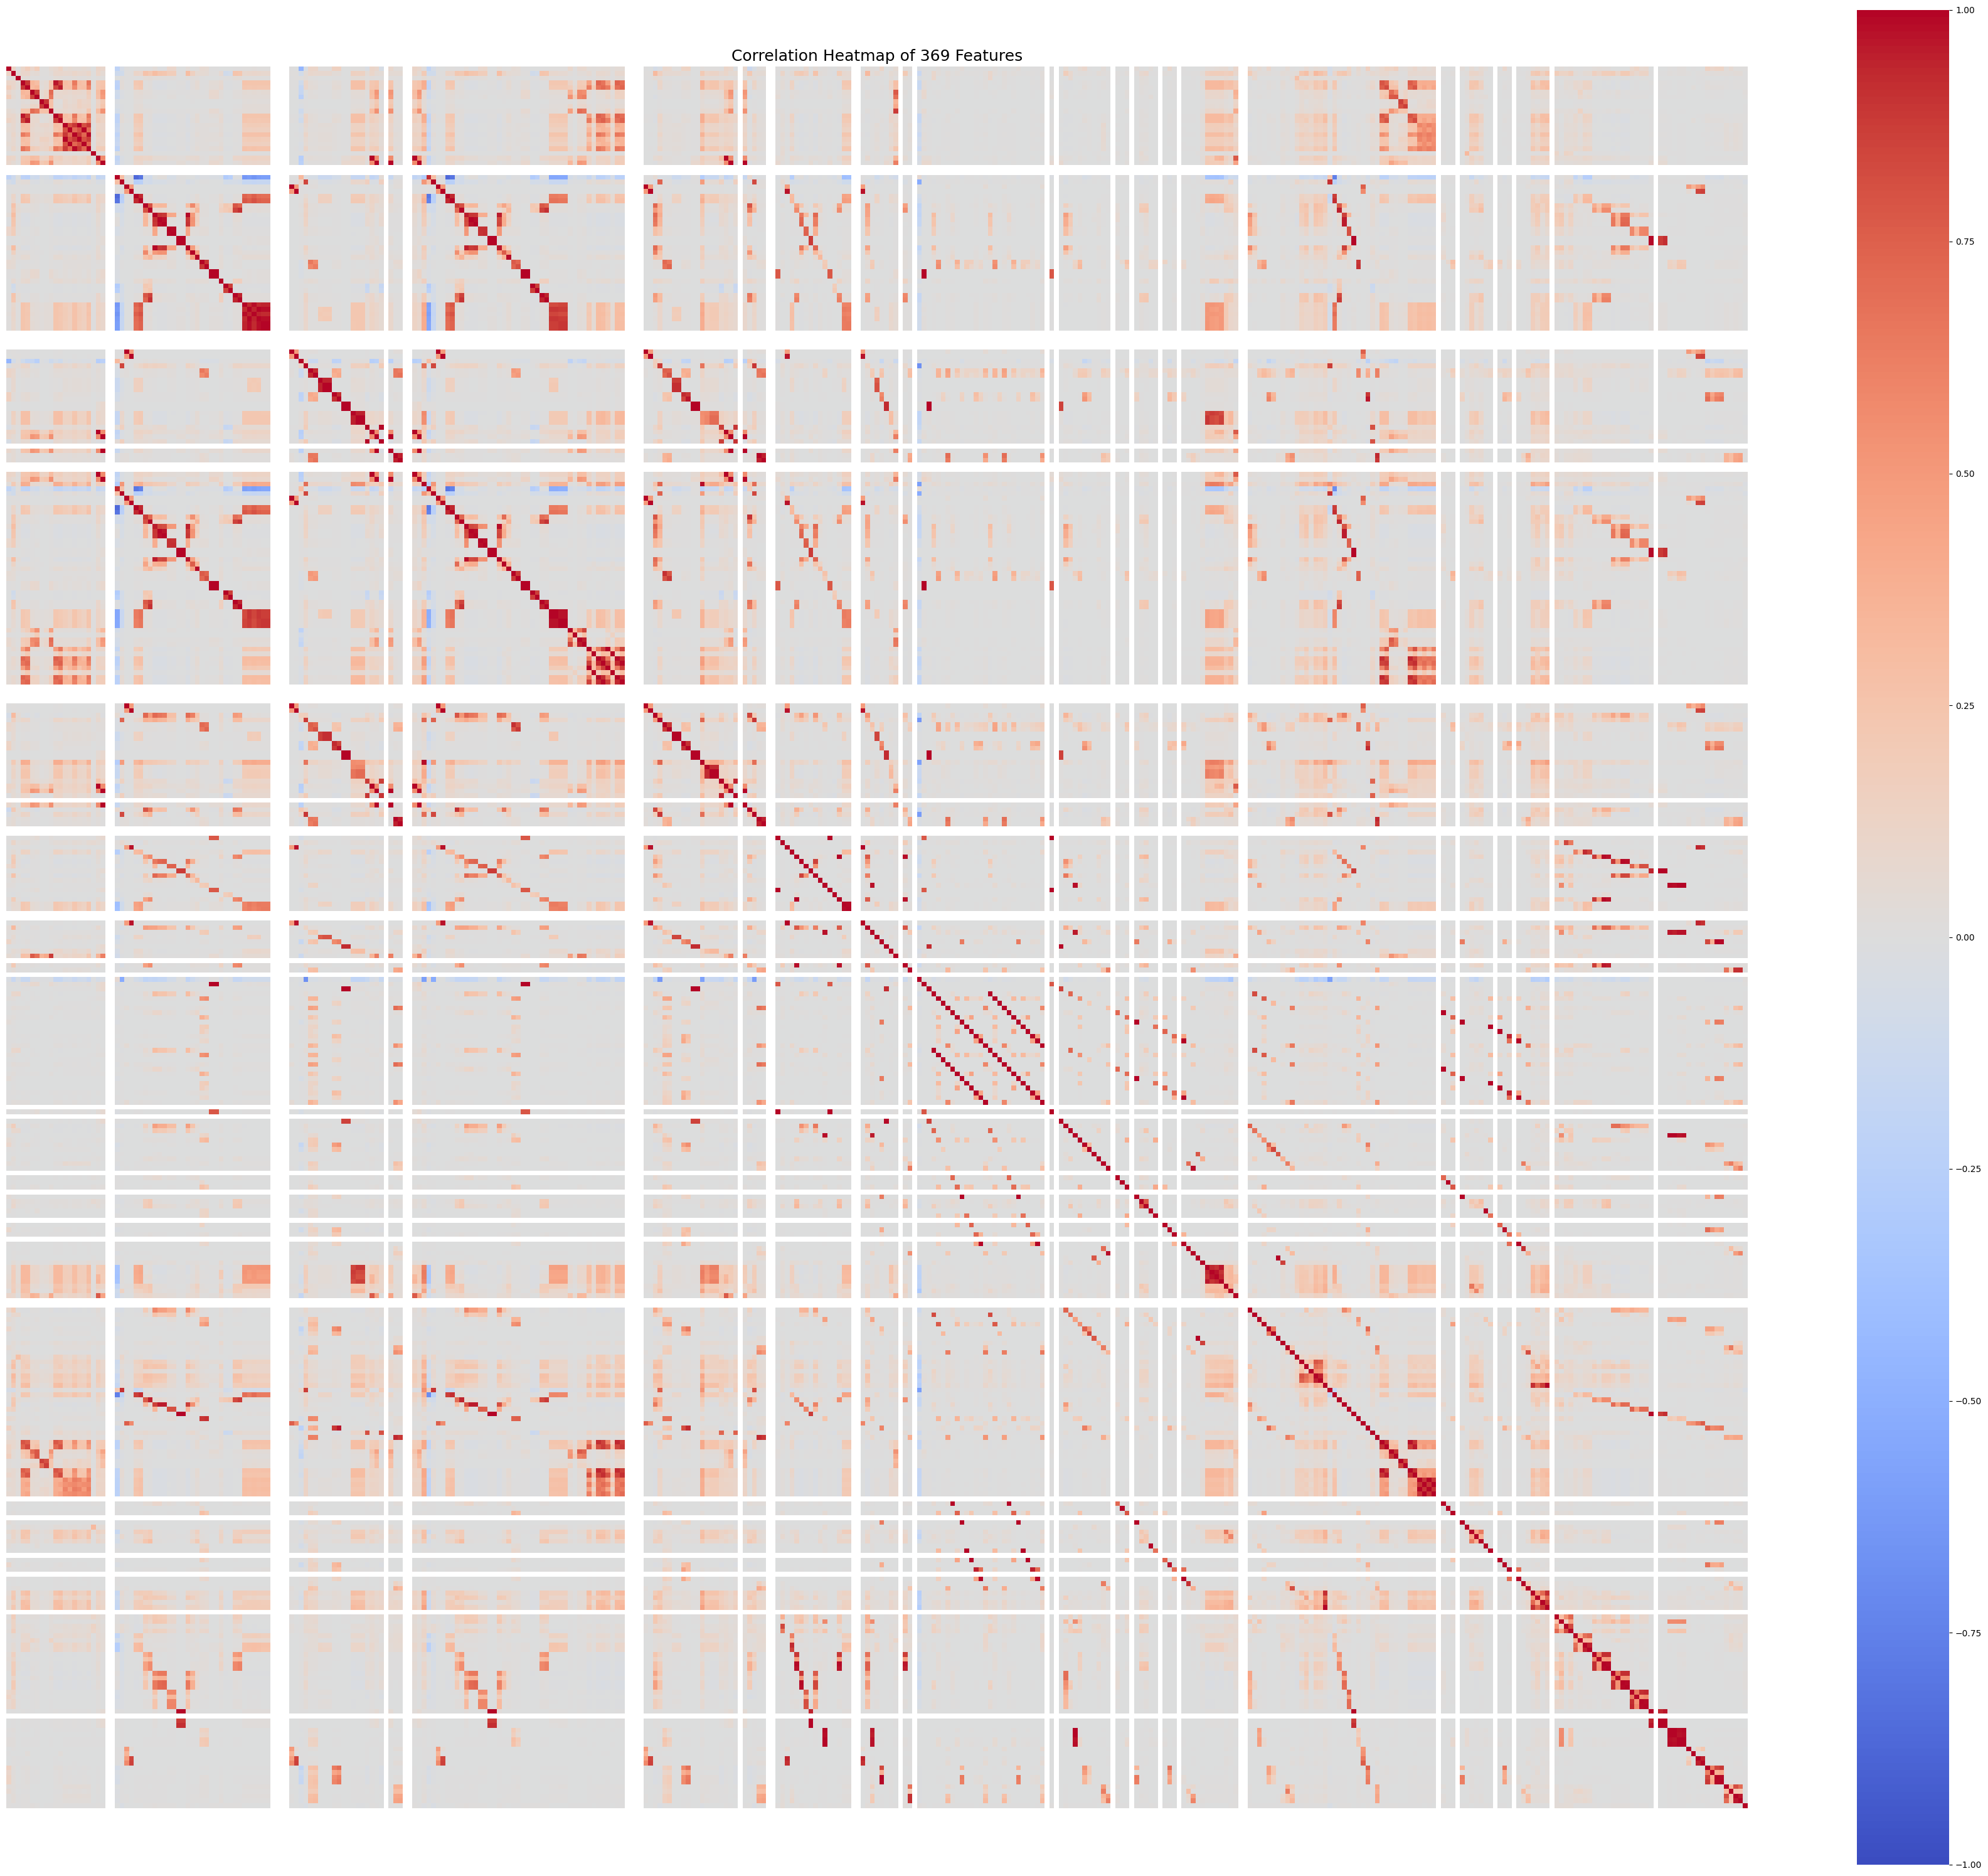

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/train.csv")

df['var3'].replace(-999999, 2, inplace=True)

# ID, TARGET 제거 → 369개 피처만 남김
df_features = df.drop(['ID', 'TARGET'], axis=1)

# 상관 행렬 계산
corr = df_features.corr()

# 히트맵
plt.figure(figsize=(35, 30))
sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    xticklabels=False,   # 369개라 너무 복잡해 숨김
    yticklabels=False
)
plt.title("Correlation Heatmap of 369 Features", fontsize=18)
plt.tight_layout()
plt.show()


In [ ]:
corr = df_features.corr()

# corr을 길게 변환
corr_long = corr.stack().reset_index()
corr_long.columns = ['Feature1', 'Feature2', 'Correlation']

# 1) 자기 자신(var3-var3 등) 제거
corr_long = corr_long[corr_long['Feature1'] != corr_long['Feature2']]

# 2) 대칭 중복 제거 (Feature 이름을 정렬한 후 중복 제거)
# (var3-var5 / var5-var3 등 제거)
corr_long['Pair'] = corr_long.apply(
    lambda row: '-'.join(sorted([row['Feature1'], row['Feature2']])),
    axis=1
)
corr_long = corr_long.drop_duplicates(subset='Pair')

# 3) 절대값 기준 정렬
corr_sorted = corr_long.reindex(
    corr_long['Correlation'].abs().sort_values(ascending=False).index
)

# 최종 출력
corr_top50 = corr_sorted[['Feature1', 'Feature2', 'Correlation']].head(50)

print(corr_top50.to_string(index=False))


                     Feature1                      Feature2  Correlation
    delta_imp_reemb_var33_1y3          imp_reemb_var33_ult1          1.0
    delta_num_reemb_var33_1y3          imp_reemb_var33_ult1          1.0
    delta_num_reemb_var13_1y3          num_reemb_var13_ult1          1.0
    delta_imp_reemb_var13_1y3          num_reemb_var13_ult1          1.0
                     ind_var8                      num_var8          1.0
delta_imp_trasp_var17_out_1y3      num_trasp_var17_out_ult1          1.0
delta_num_trasp_var17_out_1y3      num_trasp_var17_out_ult1          1.0
                  num_var18_0     delta_imp_amort_var18_1y3          1.0
                    num_var18     delta_imp_amort_var18_1y3          1.0
                    ind_var20                     num_var20          1.0
        imp_reemb_var17_hace3         num_reemb_var17_hace3          1.0
           ind_var7_emit_ult1            num_var7_emit_ult1          1.0
 delta_imp_trasp_var17_in_1y3       num_trasp_var17

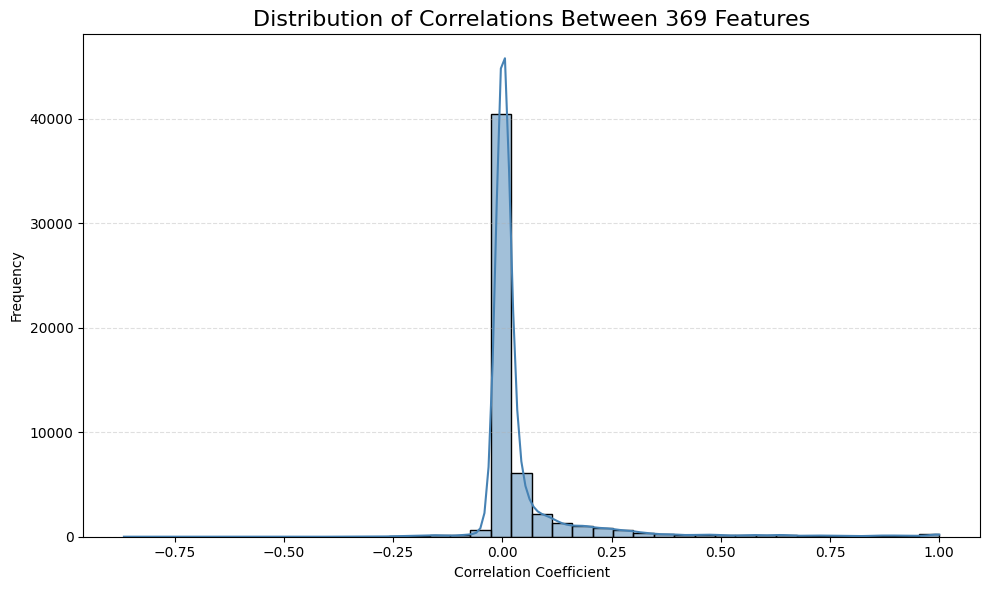

In [9]:
# ------------------------
# 상관계수 계산
# ------------------------
corr = df_features.corr()

# 상관행렬을 1차원 형태로 펼치기
# 자기 자신(1.0)도 포함되므로 제거해야 함
corr_values = corr.values.flatten()

# 자기 자신과의 상관(=1.0) 제거
corr_values = corr_values[corr_values != 1.0]

# 대칭 중복 제거 (상삼각만 사용)
corr_upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_flat = corr_upper.stack().values


plt.figure(figsize=(10, 6))
sns.histplot(corr_flat, bins=40, kde=True, color='steelblue')
plt.title("Distribution of Correlations Between 369 Features", fontsize=16)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()